In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.stats.contingency_tables import mcnemar
from itertools import combinations
import collections

In [2]:
# --- Configuration ---
# ❗️ PLEASE SET THIS PATH
# Set this to the path of the directory containing all your experiment folders.
RESULTS_PARENT_DIR = '.' # e.g., 'path/to/my/llm_results/'

# --- Data Loading Function ---
def load_evaluation_data(parent_dir):
    """
    Loads all experiment data from subdirectories of a parent directory.
    """
    all_data = []
    
    if not os.path.isdir(parent_dir):
        print(f"Error: Directory '{parent_dir}' not found. Please check the path.")
        return pd.DataFrame()

    for folder_name in os.listdir(parent_dir):
        experiment_path = os.path.join(parent_dir, folder_name)
        
        if os.path.isdir(experiment_path):
            run_details_path = os.path.join(experiment_path, 'run_details.json')
            results_path = os.path.join(experiment_path, 'results.jsonl')

            if os.path.exists(run_details_path) and os.path.exists(results_path):
                print(f"Loading data from: {folder_name}")
                with open(run_details_path, 'r', encoding='utf-8') as f:
                    run_details = json.load(f)
                
                model_name = run_details.get('config', {}).get('model_name', 'Unknown Model')
                prompt_text = run_details.get('config', {}).get('format_prompt', 'Unknown Prompt')

                with open(results_path, 'r', encoding='utf-8') as f:
                    for line in f:
                        try:
                            result = json.loads(line)
                            if result.get('successful_api_call') and result.get('model_answer') is not None and result.get('correct_answer') is not None:
                                all_data.append({
                                    'question_idx': result['idx'],
                                    'question': result['raw_data']['question'],
                                    'model_answer': result['model_answer'],
                                    'correct_answer': result['correct_answer'],
                                    'model_name': model_name,
                                    'prompt': prompt_text
                                })
                        except (json.JSONDecodeError, KeyError) as e:
                            print(f"Warning: Skipping malformed line in {results_path}: {e}")

    df = pd.DataFrame(all_data)
    if not df.empty:
        df['is_correct'] = df['model_answer'] == df['correct_answer']
    
    return df

# --- Execute Loading ---
df_raw = load_evaluation_data(RESULTS_PARENT_DIR)

if not df_raw.empty:
    print("\n✅ Data loaded successfully. Here's a preview:")
    display(df_raw.head())
    print("\nDataframe Info:")
    df_raw.info()
else:
    print("\n❌ Could not load any data. Please check the `RESULTS_PARENT_DIR` path and your folder structure.")

Loading data from: 1
Loading data from: 2
Loading data from: 3
Loading data from: 4
Loading data from: 6
Loading data from: 8

✅ Data loaded successfully. Here's a preview:


,question_idx,question,model_answer,correct_answer,model_name,prompt,is_correct
0,0,A junior orthopaedic surgery resident is compl...,A,B,meta-llama/Llama-4-Scout-17B-16E-Instruct,Only and only answer with the following format...,False
1,1,A 67-year-old man with transitional cell carci...,D,D,meta-llama/Llama-4-Scout-17B-16E-Instruct,Only and only answer with the following format...,True
2,2,Two weeks after undergoing an emergency cardia...,B,B,meta-llama/Llama-4-Scout-17B-16E-Instruct,Only and only answer with the following format...,True
3,3,A 39-year-old woman is brought to the emergenc...,B,D,meta-llama/Llama-4-Scout-17B-16E-Instruct,Only and only answer with the following format...,False
4,4,A 35-year-old man comes to the physician becau...,B,B,meta-llama/Llama-4-Scout-17B-16E-Instruct,Only and only answer with the following format...,True



Dataframe Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7488 entries, 0 to 7487
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   question_idx    7488 non-null   int64 
 1   question        7488 non-null   object
 2   model_answer    7488 non-null   object
 3   correct_answer  7488 non-null   object
 4   model_name      7488 non-null   object
 5   prompt          7488 non-null   object
 6   is_correct      7488 non-null   bool  
dtypes: bool(1), int64(1), object(5)
memory usage: 358.4+ KB


In [12]:
if not df_raw.empty:
    unique_models = df_raw['model_name'].unique()
    unique_prompts = df_raw['prompt'].unique()
    
    # Create a mapping from full prompt text to a shorter name (e.g., "Prompt 1")
    prompt_map = {prompt: f"Prompt {i+1}" for i, prompt in enumerate(unique_prompts)}
    df_raw['prompt_label'] = df_raw['prompt'].map(prompt_map)

    print("--- 🧪 Unique Models Found ---")
    for model in unique_models:
        print(f"• {model}")

    print("\n--- 📝 Unique Prompts Found ---")
    for full_prompt, label in prompt_map.items():
        print(f"• {label}: \"{full_prompt.strip()}\"")
else:
    print("DataFrame is empty. Cannot identify models and prompts.")

--- 🧪 Unique Models Found ---
• meta-llama/Llama-4-Scout-17B-16E-Instruct
• Qwen/Qwen2.5-72B-Instruct

--- 📝 Unique Prompts Found ---
• Prompt 1: "Only and only answer with the following format:
Your answer of choice should be wrapped around <a> and </a> tags.
Valid outputs:
- <a>A</a>
- <a>B</a>
- <a>C</a>
- <a>D</a>
Output no explanation, no other text, no other format. Output just two tags and the answer within them."
• Prompt 2: "Think step by step and thoroughly.
Output your reasoning and then the final answer of choice.
The final answer should be in the following format:
Your answer of choice should be wrapped around <a> and </a> tags.
Valid final answers:
- <a>A</a>
- <a>B</a>
- <a>C</a>
- <a>D</a>"
• Prompt 3: "Think step by step and thoroughly. Use abductive reasoning process to reason about the question and the answer choices.
Output your reasoning and then the final answer of choice.
The final answer should be in the following format:
Your answer of choice should be wrapped 

In [4]:
if not df_raw.empty:
    # Create a unique identifier for each experiment run
    df_raw['run_id'] = df_raw['model_name'] + " | " + df_raw['prompt_label']
    
    # Count how many unique runs each question appears in
    question_counts = df_raw.groupby('question_idx')['run_id'].nunique()
    
    # Get the total number of unique runs
    total_runs = df_raw['run_id'].nunique()
    
    # Find the indices of questions that appear in ALL runs
    common_question_indices = question_counts[question_counts == total_runs].index
    
    # Filter the DataFrame to only include these common questions
    df_intersect = df_raw[df_raw['question_idx'].isin(common_question_indices)].copy()
    
    print(f"Total unique questions across all files: {df_raw['question_idx'].nunique()}")
    print(f"Total number of unique experiment runs: {total_runs}")
    print(f"Number of questions in the fair comparison set: {len(common_question_indices)}")
    
    if len(common_question_indices) == 0:
        print("\n❌ WARNING: No questions were successfully answered by all runs. Cannot perform a fair comparison.")
    else:
        print("\n✅ Filtered DataFrame for analysis is now ready.")
        display(df_intersect.head())
else:
    print("DataFrame is empty.")

Total unique questions across all files: 1273
Total number of unique experiment runs: 6
Number of questions in the fair comparison set: 1143

✅ Filtered DataFrame for analysis is now ready.


,question_idx,question,model_answer,correct_answer,model_name,prompt,is_correct,prompt_label,run_id
0,0,A junior orthopaedic surgery resident is compl...,A,B,meta-llama/Llama-4-Scout-17B-16E-Instruct,Only and only answer with the following format...,False,Prompt 1,meta-llama/Llama-4-Scout-17B-16E-Instruct | Pr...
1,1,A 67-year-old man with transitional cell carci...,D,D,meta-llama/Llama-4-Scout-17B-16E-Instruct,Only and only answer with the following format...,True,Prompt 1,meta-llama/Llama-4-Scout-17B-16E-Instruct | Pr...
2,2,Two weeks after undergoing an emergency cardia...,B,B,meta-llama/Llama-4-Scout-17B-16E-Instruct,Only and only answer with the following format...,True,Prompt 1,meta-llama/Llama-4-Scout-17B-16E-Instruct | Pr...
3,3,A 39-year-old woman is brought to the emergenc...,B,D,meta-llama/Llama-4-Scout-17B-16E-Instruct,Only and only answer with the following format...,False,Prompt 1,meta-llama/Llama-4-Scout-17B-16E-Instruct | Pr...
4,4,A 35-year-old man comes to the physician becau...,B,B,meta-llama/Llama-4-Scout-17B-16E-Instruct,Only and only answer with the following format...,True,Prompt 1,meta-llama/Llama-4-Scout-17B-16E-Instruct | Pr...


--- 📊 Accuracy per Model and Prompt ---


prompt_label,Prompt 1,Prompt 2,Prompt 3
model_name,,,
Qwen/Qwen2.5-72B-Instruct,74.45%,80.75%,81.63%
meta-llama/Llama-4-Scout-17B-16E-Instruct,76.99%,84.43%,79.70%


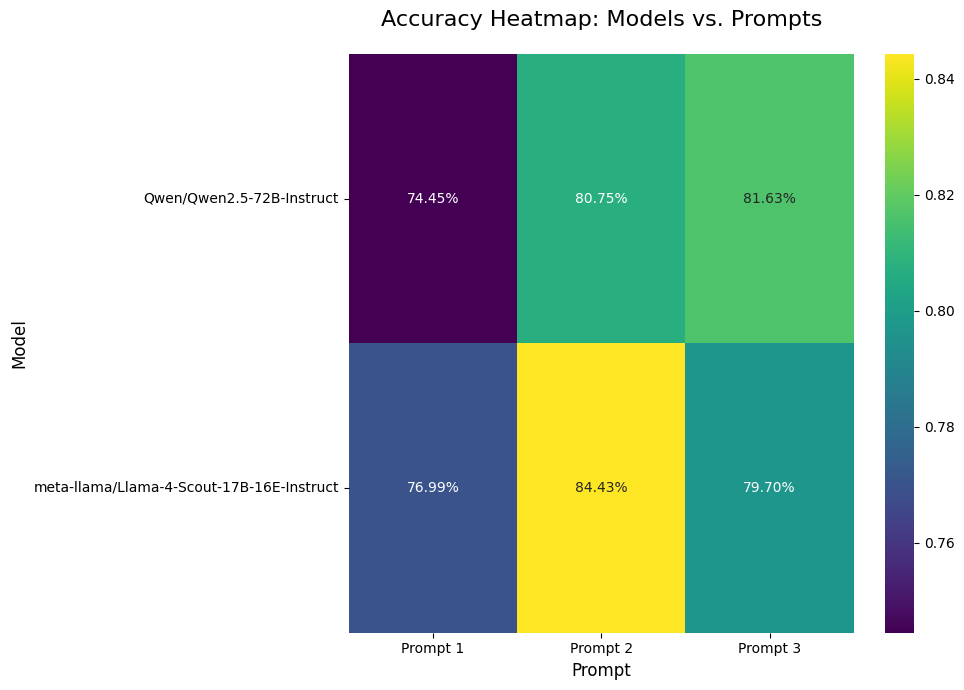

In [5]:
if 'df_intersect' in locals() and not df_intersect.empty:
    # Calculate accuracy for each group using the prompt labels
    accuracy_df = df_intersect.groupby(['model_name', 'prompt_label'])['is_correct'].mean().reset_index()
    accuracy_df = accuracy_df.rename(columns={'is_correct': 'accuracy'})
    
    # Create a pivot table
    accuracy_pivot = accuracy_df.pivot(index='model_name', columns='prompt_label', values='accuracy')
    
    print("--- 📊 Accuracy per Model and Prompt ---")
    display(accuracy_pivot.style.format("{:.2%}"))

    # Plotting the heatmap
    plt.figure(figsize=(10, 7))
    sns.heatmap(accuracy_pivot, annot=True, cmap='viridis', fmt=".2%")
    plt.title('Accuracy Heatmap: Models vs. Prompts', fontsize=16, pad=20)
    plt.xlabel('Prompt', fontsize=12)
    plt.ylabel('Model', fontsize=12)
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Filtered DataFrame `df_intersect` is not available or empty.")

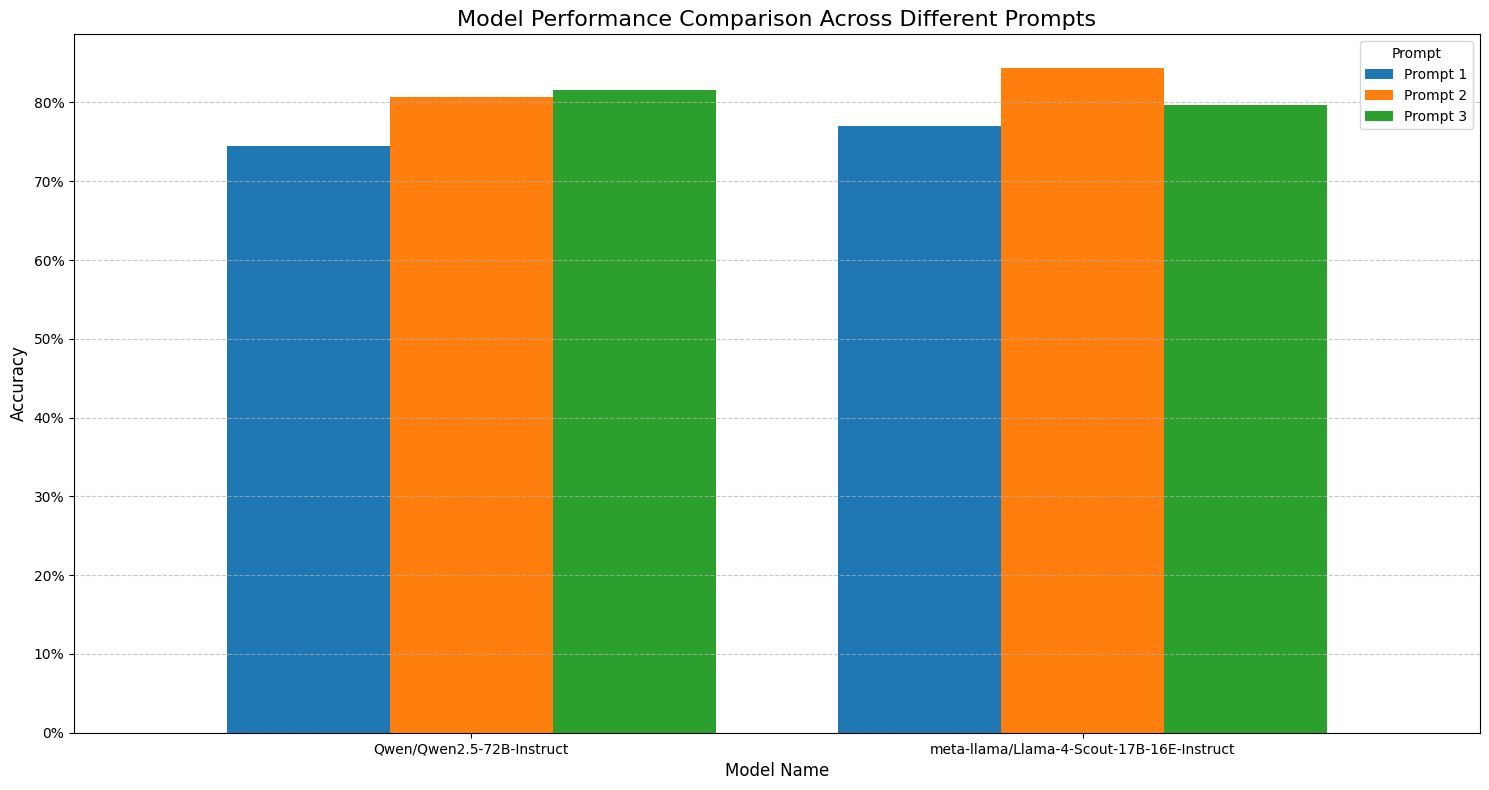

In [6]:
if 'accuracy_pivot' in locals() and not accuracy_pivot.empty:
    accuracy_pivot.plot(
        kind='bar',
        figsize=(15, 8),
        width=0.8,
        rot=0
    )
    plt.title('Model Performance Comparison Across Different Prompts', fontsize=16)
    plt.ylabel('Accuracy', fontsize=12)
    plt.xlabel('Model Name', fontsize=12)
    plt.legend(title='Prompt')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter('{:.0%}'.format)) # Format y-axis as percentage
    plt.tight_layout()
    plt.show()
else:
    print("Accuracy pivot table not available for plotting.")

In [7]:
if 'df_intersect' in locals() and not df_intersect.empty:
    unique_prompt_labels = df_intersect['prompt_label'].unique()
    unique_models_list = df_intersect['model_name'].unique()

    for p_label in unique_prompt_labels:
        print(f"--- 🔬 Significance Testing for {p_label} ---\n")
        
        prompt_df = df_intersect[df_intersect['prompt_label'] == p_label]
        model_pairs = list(combinations(unique_models_list, 2))
        
        results = []
        for model1, model2 in model_pairs:
            m1_results = prompt_df[prompt_df['model_name'] == model1]['is_correct'].values
            m2_results = prompt_df[prompt_df['model_name'] == model2]['is_correct'].values
            
            # Contingency table for McNemar's test
            yes_no = np.sum((m1_results == True) & (m2_results == False))
            no_yes = np.sum((m1_results == False) & (m2_results == True))
            
            table = [[np.sum((m1_results == True) & (m2_results == True)), yes_no], 
                     [no_yes, np.sum((m1_results == False) & (m2_results == False))]]
            
            # The test statistic is based on cases where models disagree
            if yes_no + no_yes > 0:
                result = mcnemar(table, exact=True)
                p_value = result.pvalue
                results.append({
                    'Comparison': f"{model1} vs {model2}",
                    'p-value': p_value,
                    'Significant (p<0.05)': '✅ Yes' if p_value < 0.05 else '❌ No'
                })
            else:
                 results.append({
                    'Comparison': f"{model1} vs {model2}",
                    'p-value': 1.0,
                    'Significant (p<0.05)': 'Identical'
                })
        
        if results:
            significance_df = pd.DataFrame(results).set_index('Comparison')
            display(significance_df.style.format({'p-value': '{:.4f}'}))
        else:
            print("Not enough model pairs to perform significance testing.")
            
        print("\n" + "="*80 + "\n")
else:
    print("Filtered DataFrame `df_intersect` not available for significance testing.")

--- 🔬 Significance Testing for Prompt 1 ---



,p-value,Significant (p<0.05)
Comparison,,
meta-llama/Llama-4-Scout-17B-16E-Instruct vs Qwen/Qwen2.5-72B-Instruct,0.0571,❌ No




--- 🔬 Significance Testing for Prompt 2 ---



,p-value,Significant (p<0.05)
Comparison,,
meta-llama/Llama-4-Scout-17B-16E-Instruct vs Qwen/Qwen2.5-72B-Instruct,0.0080,✅ Yes




--- 🔬 Significance Testing for Prompt 3 ---



,p-value,Significant (p<0.05)
Comparison,,
meta-llama/Llama-4-Scout-17B-16E-Instruct vs Qwen/Qwen2.5-72B-Instruct,0.1910,❌ No


C:\Users\Shaygan.DESKTOP-KS933FB\AppData\Local\Temp\ipykernel_7424\1462771820.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  length_accuracy = df_intersect.groupby(['length_bin', 'model_name'])['is_correct'].mean().reset_index()


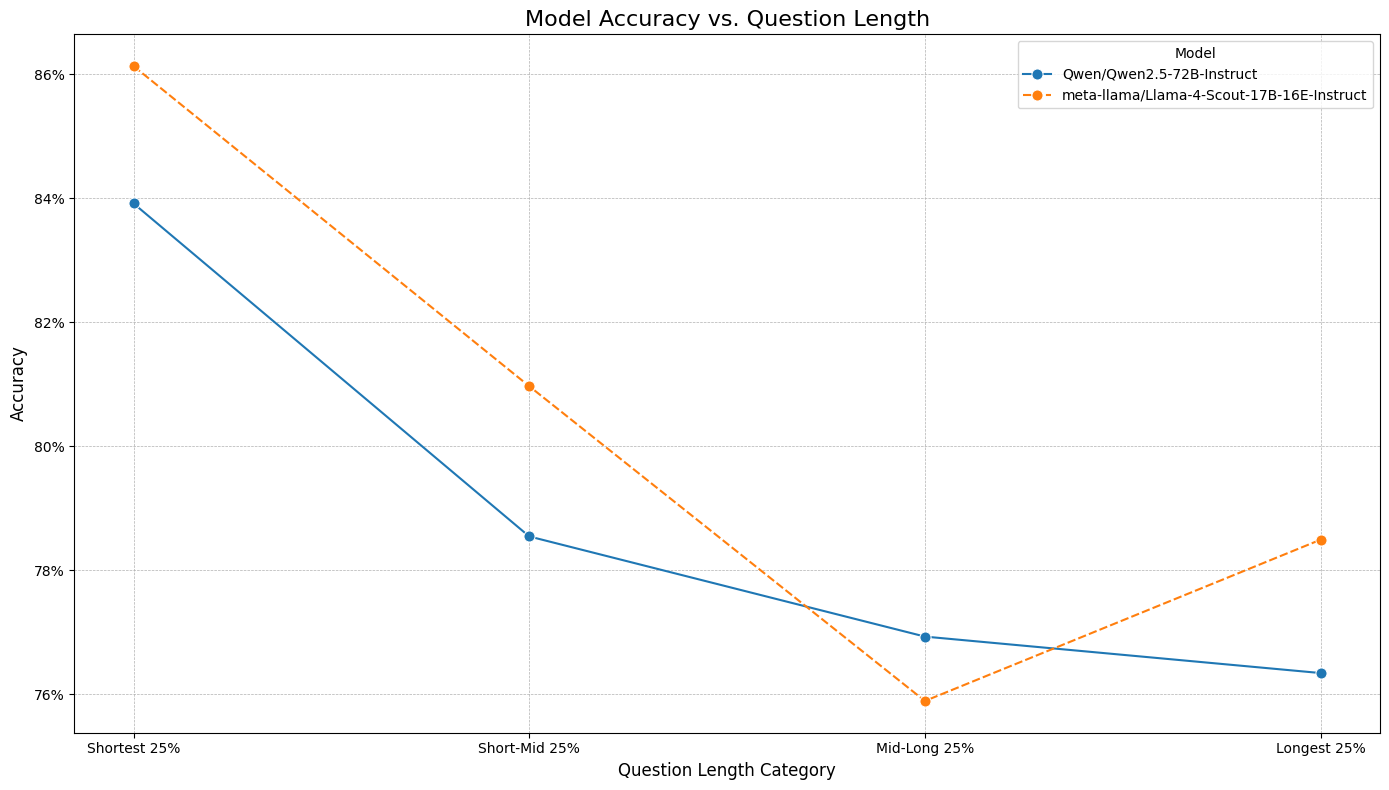

In [8]:
if 'df_intersect' in locals() and not df_intersect.empty:
    # Calculate question length (by number of words)
    df_intersect['question_length'] = df_intersect['question'].apply(lambda x: len(x.split()))
    
    # Create 4 bins for question length using quantiles for equal size
    df_intersect['length_bin'] = pd.qcut(df_intersect['question_length'], q=4, labels=['Shortest 25%', 'Short-Mid 25%', 'Mid-Long 25%', 'Longest 25%'])
    
    # Calculate accuracy per bin
    length_accuracy = df_intersect.groupby(['length_bin', 'model_name'])['is_correct'].mean().reset_index()
    
    # Plotting
    plt.figure(figsize=(14, 8))
    sns.lineplot(
        data=length_accuracy,
        x='length_bin',
        y='is_correct',
        hue='model_name',
        marker='o',
        markersize=8,
        style='model_name'
    )
    plt.title('Model Accuracy vs. Question Length', fontsize=16)
    plt.xlabel('Question Length Category', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend(title='Model')
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter('{:.0%}'.format))
    plt.tight_layout()
    plt.show()

else:
    print("Filtered DataFrame `df_intersect` not available.")

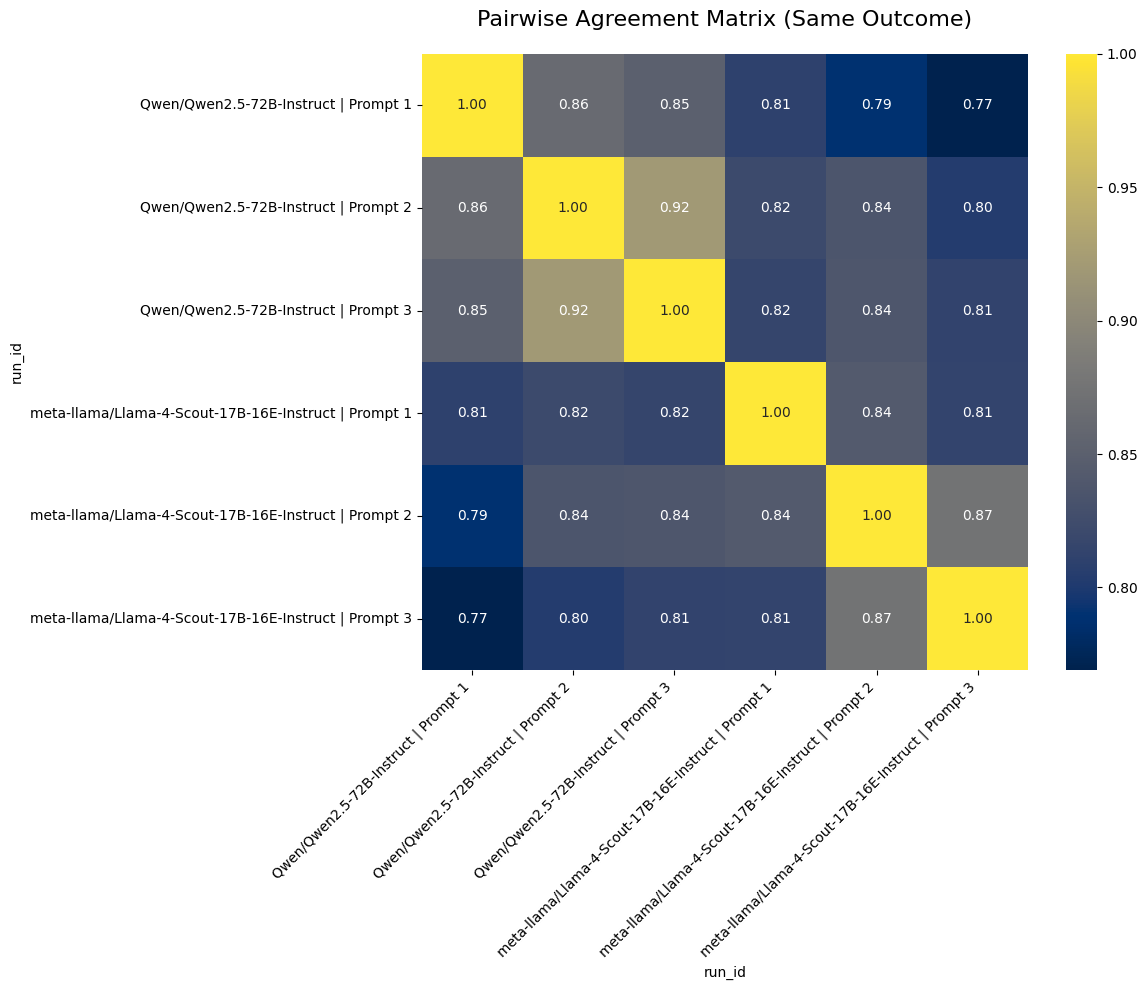

In [9]:
if 'df_intersect' in locals() and not df_intersect.empty:
    # Pivot the data to have questions as rows and runs as columns
    correctness_pivot = df_intersect.pivot_table(
        index='question_idx', 
        columns='run_id', 
        values='is_correct'
    )

    # Calculate pairwise agreement
    run_ids = correctness_pivot.columns
    agreement_matrix = pd.DataFrame(index=run_ids, columns=run_ids, dtype=float)

    for run1 in run_ids:
        for run2 in run_ids:
            agreement = np.mean(correctness_pivot[run1] == correctness_pivot[run2])
            agreement_matrix.loc[run1, run2] = agreement
            
    # Plotting the heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(agreement_matrix, annot=True, cmap='cividis', fmt=".2f")
    plt.title('Pairwise Agreement Matrix (Same Outcome)', fontsize=16, pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Filtered DataFrame `df_intersect` not available.")

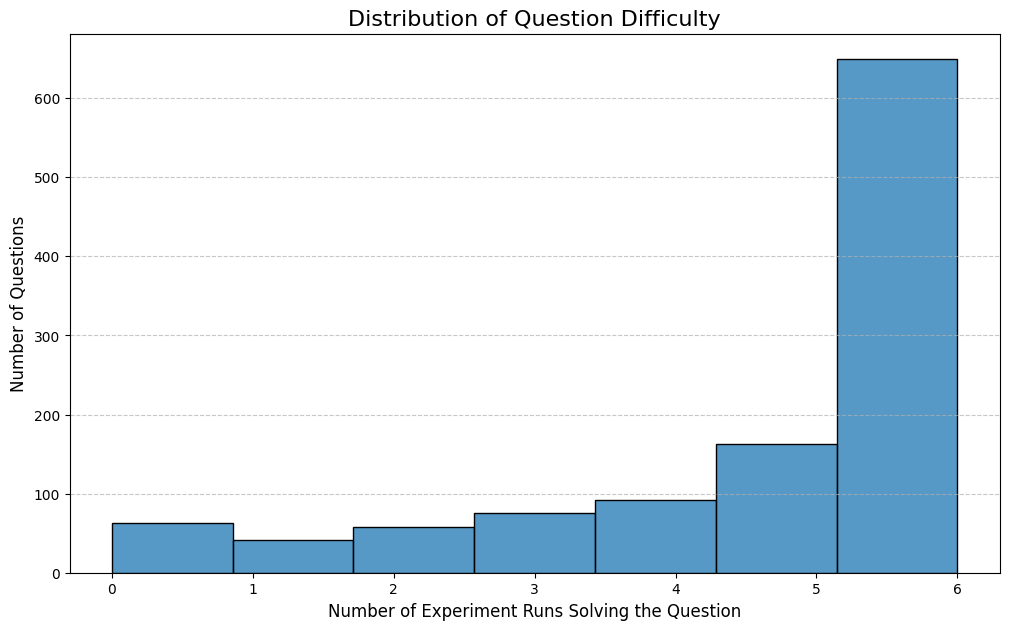


--- Question Difficulty Stats ---
Easiest Questions (solved by all 6 runs): 649 questions
Hardest Questions (solved by 0 runs): 63 questions


In [10]:
if 'correctness_pivot' in locals() and not correctness_pivot.empty:
    # Sum across the columns to see how many runs solved each question
    solves_per_question = correctness_pivot.sum(axis=1)
    
    # Plotting the distribution
    plt.figure(figsize=(12, 7))
    sns.histplot(solves_per_question, bins=len(correctness_pivot.columns) + 1, kde=False)
    
    plt.title('Distribution of Question Difficulty', fontsize=16)
    plt.xlabel('Number of Experiment Runs Solving the Question', fontsize=12)
    plt.ylabel('Number of Questions', fontsize=12)
    plt.xticks(range(len(correctness_pivot.columns) + 1))
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    
    print("\n--- Question Difficulty Stats ---")
    print(f"Easiest Questions (solved by all {total_runs} runs): {np.sum(solves_per_question == total_runs)} questions")
    print(f"Hardest Questions (solved by 0 runs): {np.sum(solves_per_question == 0)} questions")

else:
    print("Correctness pivot table not available.")

In [11]:
if 'solves_per_question' in locals():
    # Find the indices of questions solved by zero models
    hardest_question_indices = solves_per_question[solves_per_question == 0].index

    if len(hardest_question_indices) > 0:
        print(f"--- 🧐 Examining the {len(hardest_question_indices)} Hardest Questions (Solved by None) ---\n")
        
        # Get the original question data for these indices
        hardest_questions_df = df_raw[df_raw['question_idx'].isin(hardest_question_indices)].drop_duplicates(subset=['question_idx'])
        
        for i, row in hardest_questions_df.head(5).iterrows(): # Display up to 5 examples
            print(f"Question Index: {row['question_idx']}")
            print(f"Question: {row['question']}")
            print(f"Correct Answer: {row['correct_answer']}")
            print("-" * 50)
    else:
        print("🎉 No questions were missed by all models! All questions were solved by at least one run.")
else:
    print("Analysis on question difficulty has not been run yet.")

--- 🧐 Examining the 63 Hardest Questions (Solved by None) ---

Question Index: 5
Question: A 39-year-old man presents to the emergency department because of progressively worsening chest pain and nausea that started at a local bar 30 minutes prior. The pain radiates to the epigastric area. He has a 5-year history of untreated hypertension. He has smoked 1 pack of cigarettes daily for the past 5 years and started abusing cocaine 2 weeks before his emergency room visit. The patient is diaphoretic and in marked distress. What should be the first step in management?
Correct Answer: D
--------------------------------------------------
Question Index: 33
Question: An otherwise healthy 50-year-old man comes to the physician because of a 6-month history of increasingly frequent episodes of upper abdominal pain, nausea, vomiting, and diarrhea. He has had a 3.2-kg (7-lb) weight loss during this time. Physical examination shows bilateral pitting pedal edema. An endoscopy shows prominent rugae in 